# Overview - Portfolio Optimization Example

* Select data according to lookback and lookahead
* Filter data (remove stocks with bad data availability) - works on lookback period
* Select stocks by metric (narrow the stock universe by preference) - works on lookback period
* Determine weights (naive, mcap, optimized) - works on lookback period 
* Determine portfolio returns - works on lookahead sample
* Evaluate whole out of time period - works on recorded out of sample period

## Methods, Packages and Class Definitions

In [1]:
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf
import cvxpy as cp
from tqdm.auto import tqdm
from functools import partial
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# method to remove stocks with bad data availabilty
def filter_universe(
    panel: pd.DataFrame,
    *,
    max_missing_frac: float = 0.10,
    return_col: str = "Return",
    id_col: str = "DSCD",
    date_col: str = "Date",          
) -> list:

    total_trading_days = panel[date_col].nunique()   # ← denominator for coverage

    valid = []
    for dscd, grp in panel.groupby(id_col, sort=False):
        ret = grp[return_col].dropna()
        ret = ret[ret != 0]

        # Coverage relative to the full estimation window, not just the stock's own rows
        coverage_frac = len(ret) / total_trading_days
        if (1 - coverage_frac) > max_missing_frac:
            continue

        valid.append(dscd)

    return valid

# for the moment select stock to invest by highest past pseudo Sharpe-ratio
def metric_sharpe(ret_mat):
    return ret_mat.mean() / ret_mat.std(ddof = 1)


def select_stocks(
        ret_mat: pd.DataFrame,
        scoring_metric: callable,
        n_stocks: int,
        ascending: bool = False
) -> list:
    scores = scoring_metric(ret_mat)
    return scores.sort_values(ascending = ascending).head(n_stocks).index.tolist()

# helper to transform a dataframe in long format to the return matrix in wide format
def panel_to_ret_matrix(
        panel: pd.DataFrame,
        return_col: str = "Return",
        id_col: str = "DSCD",
        date_col: str = "Date"
) -> pd.DataFrame:
    return panel.loc[:, [date_col, id_col, return_col]].pivot(index = date_col, columns = id_col, values = return_col)

# two options for estimating the covariance matrix for return matrix
def covariance_estimator(ret_mat: pd.DataFrame, method: str = "sample"):
    R = ret_mat.dropna(how="all").fillna(0).multiply(100)
    if method == "sample":
        Sigma = R.cov().values
    elif method == "ledoit_wolf":
        lw = LedoitWolf().fit(R.values)
        Sigma = lw.covariance_
    
    ridge: float = 1e-4
    # Ridge regularisation: adds eps to diagonal, guarantees PD - otherwise fails sometimes for sample estimator
    Sigma = Sigma + ridge * np.eye(Sigma.shape[0])
    
    # Return as DataFrame to preserve column index downstream
    return pd.DataFrame(Sigma, index=ret_mat.columns, columns=ret_mat.columns)


### Weight determination
def naive_weights(Sigma: pd.DataFrame, **kwargs):
    N = Sigma.shape[0]
    return pd.Series(np.ones(N) / N, index = Sigma.index)

def mcap_weights(panel_selected: pd.DataFrame, mcap_col: str, id_col: str, **kwargs):    
    last_mcap = (
        panel_selected
        .assign(MarketCAP = lambda df: df[mcap_col].replace(0, np.nan))
        .groupby(id_col)[mcap_col]
        .last(skipna = True)
    )

    return last_mcap / last_mcap.sum()

def min_variance_weights(Sigma: pd.DataFrame, **kwargs):
    S = cp.psd_wrap(Sigma.values)   # tell CVXPY to trust it is PSD
    x = cp.Variable(S.shape[0])
    constraints = [x >= 0.0, x <= 1.0, x.sum() == 1.0]
    prob = cp.Problem(cp.Minimize(cp.quad_form(x, S)), constraints)
    prob.solve()

    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        raise ValueError(f"Optimisation failed with status: {prob.status}")
    
    return pd.Series(x.value.round(6), index=Sigma.index)

# this is a helper to unify the different weight determination methods from above
def compute_weights(weight_fn: callable, **kwargs) -> pd.Series:
    return weight_fn(**kwargs)
###


# helper method if stocks selected are not available in the holding period
def redistribute_weights(w: pd.Series, ret_hold: pd.DataFrame) -> pd.Series:
    """
    Redistribute weight of stocks absent from the holding period
    proportionally to the stocks that are present.
    A stock is considered absent if it has zero returns on ALL holding days
    AND was not in the holding panel at all.
    """
    present_ids = set(ret_hold.columns)
    present_mask = w.index.isin(present_ids)
    
    if present_mask.all():
        return w  # nothing to do
    
    w_adj = w.copy()
    lost_weight = w_adj[~present_mask].sum()
    w_adj[~present_mask] = 0.0
    
    # redistribute proportionally among present stocks
    if w_adj[present_mask].sum() > 0:
        w_adj[present_mask] *= (1 + lost_weight / w_adj[present_mask].sum())
    
    return w_adj[present_mask]


# a class for investors with different styles and preferences
class Investor:
    def __init__(self, strategy: str, covar_estimation: str = "sample"):
        self.strategy = strategy
        self.covar_estimation = covar_estimation
        self.holding_weights = []
        self.holding_returns = []

        if self.strategy == "naive":
            self.weights = partial(compute_weights, weight_fn=naive_weights)
        elif self.strategy == "mcap":
            self.weights = partial(compute_weights, weight_fn=mcap_weights)
        elif self.strategy == "min_variance":
            self.weights = partial(compute_weights, weight_fn=min_variance_weights)

        if self.covar_estimation == "ledoit_wolf":
            self.covar_est = partial(covariance_estimator, method = "ledoit_wolf")  
        else:
            self.covar_est = partial(covariance_estimator, method = "sample")
        

    def get_returns(self, w: pd.Series, ret_mat: pd.Series):
        pf_returns = ret_mat.loc[:, w.index].values @ w.values
        self.holding_weights.append(w)
        self.holding_returns.append(pd.Series(pf_returns, index = ret_mat.index))


### methods for evaluation
def evaluate_portfolio(returns: pd.Series, ann_factor: int = 252) -> pd.Series:
    """
    Evaluate a daily portfolio return series.

    Parameters
    ----------
    returns    : pd.Series of daily portfolio returns
    ann_factor : trading days per year (default 252)
    """
    # Annualised mean and volatility
    ann_mean = returns.mean() * ann_factor
    ann_std  = returns.std(ddof=1) * np.sqrt(ann_factor)

    # Pseudo Sharpe (no risk-free rate adjustment)
    sharpe = ann_mean / ann_std if ann_std > 0 else np.nan

    # Value-at-Risk: 1% left-tail quantile (loss expressed as negative number)
    var_01 = returns.quantile(0.01)

    # Expected Shortfall: mean of returns below the 2.5% quantile
    threshold = returns.quantile(0.025)
    es_025 = returns[returns <= threshold].mean()

    # Maximum drawdown
    wealth   = (1 + returns).cumprod()
    peak     = wealth.cummax()
    drawdown = (wealth - peak) / peak
    max_dd   = drawdown.min()

    return pd.Series({
        "Ann. Mean":          ann_mean,
        "Ann. Std":           ann_std,
        "Sharpe Ratio":       sharpe,
        "VaR (1%)":          var_01,
        "ES (2.5%)":         es_025,
        "Max Drawdown":       max_dd,
    })


def plot_portfolios(returns_df: pd.DataFrame, figsize: tuple = (14, 5)) -> None:
    """
    Plot cumulative wealth (left) and daily returns (right) for each portfolio.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Daily returns with datetime index, one column per portfolio.
    figsize    : tuple
    """
    wealth_df = (1 + returns_df).cumprod()

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=figsize)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # ── Left: cumulative wealth ────────────────────────────────────────
    for (col, series), color in zip(wealth_df.items(), colors):
        ax_left.plot(series.index, series.values, label=col, color=color, linewidth=1.2)

    ax_left.set_title("Cumulative Wealth")
    ax_left.set_ylabel("Growth of $1")
    ax_left.axhline(1.0, color="black", linewidth=0.6, linestyle="--")
    ax_left.legend(frameon=False)
    ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_left.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax_left.get_xticklabels(), rotation=45, ha="right")

    # ── Right: daily returns ───────────────────────────────────────────
    for (col, series), color in zip(returns_df.items(), colors):
        ax_right.plot(series.index, series.values, label=col, color=color,
                      linewidth=0.6, alpha=0.8)

    ax_right.set_title("Daily Returns")
    ax_right.set_ylabel("Return")
    ax_right.axhline(0.0, color="black", linewidth=0.6, linestyle="--")
    ax_right.legend(frameon=False)
    ax_right.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_right.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax_right.get_xticklabels(), rotation=45, ha="right")

    fig.tight_layout()
    plt.show()

c:\Users\phili\miniconda3\envs\phpo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Determine weights and portfolio returns over time

In [2]:
# import data
df = pd.read_feather("./Data/US_datastream/US_data_panel_filtered_0.15.feather")
df = df.sort_values(by = "Date")

estimation_window = 512
holding_period = 21
 
date_col = "Date"
return_col = "Return"
id_col = "DSCD"

# All unique trading dates, sorted
all_dates = np.sort(df[date_col].unique())
T = len(all_dates)

# Slide the estimation window forward by holding_period steps
start_idx = estimation_window
rebalance_indices = range(start_idx, T, holding_period)

# initialize investors
investors = {}
investors["naive"] = Investor(strategy = "naive")
investors["mcap"] = Investor(strategy = "mcap")
investors["min_variance_sample"] = Investor(strategy = "min_variance", covar_estimation = "sample")
investors["min_variance_lw"] = Investor(strategy = "min_variance", covar_estimation = "ledoit_wolf")

for i, t_idx in enumerate(tqdm(rebalance_indices)):

    # ── Estimation window ──────────────────────────────────────
    est_start = all_dates[t_idx - estimation_window]
    est_end   = all_dates[t_idx - 1]
    hold_end_idx = min(t_idx + holding_period, T)
    hold_dates = all_dates[t_idx:hold_end_idx]
    panel = df[(df[date_col] >= est_start) & (df[date_col] <= est_end)]
    
    # remove non-valid companies
    valid_ids = filter_universe(panel, max_missing_frac=0.1, return_col = return_col, id_col = id_col, date_col = date_col)
    panel_valid = panel[panel[id_col].isin(valid_ids)]
    ret_valid = panel_to_ret_matrix(panel_valid, return_col = return_col, id_col = id_col, date_col = date_col)

    # select stocks for optimization
    selected_ids = select_stocks(ret_valid, metric_sharpe, n_stocks=50, ascending=False)
    panel_selected = panel_valid[panel_valid[id_col].isin(selected_ids)]
    ret_selected = ret_valid.loc[:, selected_ids]

    # sort for alignment with stock id
    ret_selected = ret_selected.loc[:, ret_selected.columns.sort_values()]

    # get return observations over time
    R = ret_selected.dropna(how="all").fillna(0) 

    for _, investor in investors.items():
        Sigma_tmp = investor.covar_est(R)
        w = investor.weights(Sigma = Sigma_tmp, panel_selected = panel_selected, mcap_col = "MarketCAP", id_col = "DSCD") # the last three arguments are only used by the market cap strategy
        w = w.sort_index()
        sorted_ids = w.index.tolist()

        panel_hold = df[(df[date_col].isin(hold_dates)) & (df[id_col].isin(selected_ids))]
        ret_hold = (
            panel_to_ret_matrix(panel_hold, return_col=return_col, id_col=id_col, date_col=date_col)
            .reindex(index=hold_dates, columns=sorted_ids)   # align both axes
            .fillna(0.0)
        )


        # NAs happen usually only happen here if no market cap values are available for an id over the whole lookback estimation period
        # if they do, the stock is dropped and removed from the holding period return matrix
        not_available_ids = w[w.isna()].index.tolist()
        w = w.dropna()
        available_ids = w.sort_index().index.tolist()
        ret_hold = ret_hold.loc[:, available_ids]

        # if an id for which weights exists has no data in the holding period (the column does not exist in the holding period return matrix)
        # the weight is proportionally redistributed and removed from the weights
        w = redistribute_weights(w, ret_hold)

        investor.get_returns(w, ret_hold)

100%|██████████| 363/363 [51:51<00:00,  8.57s/it]


## Summary and Visualization

In [3]:
portfolio_evaluations = []
portfolio_timeseries = []
for strategy, investor in investors.items():
    return_history = pd.concat(investor.holding_returns)
    portfolio_timeseries.append(return_history.to_frame(strategy))
    results_tmp = evaluate_portfolio(return_history)
    portfolio_evaluations.append(results_tmp.to_frame(strategy))
    
summary = pd.concat(portfolio_evaluations, axis = 1)
summary

,naive,mcap,min_variance_sample,min_variance_lw
Ann. Mean,0.115992,0.160521,0.071815,0.071009
Ann. Std,0.215720,0.263244,0.077663,0.083521
Sharpe Ratio,0.537695,0.609782,0.924697,0.850193
VaR (1%),-0.041663,-0.049054,-0.015346,-0.016134
ES (2.5%),-0.042998,-0.050066,-0.015813,-0.017100
Max Drawdown,-0.609610,-0.694478,-0.273221,-0.265995


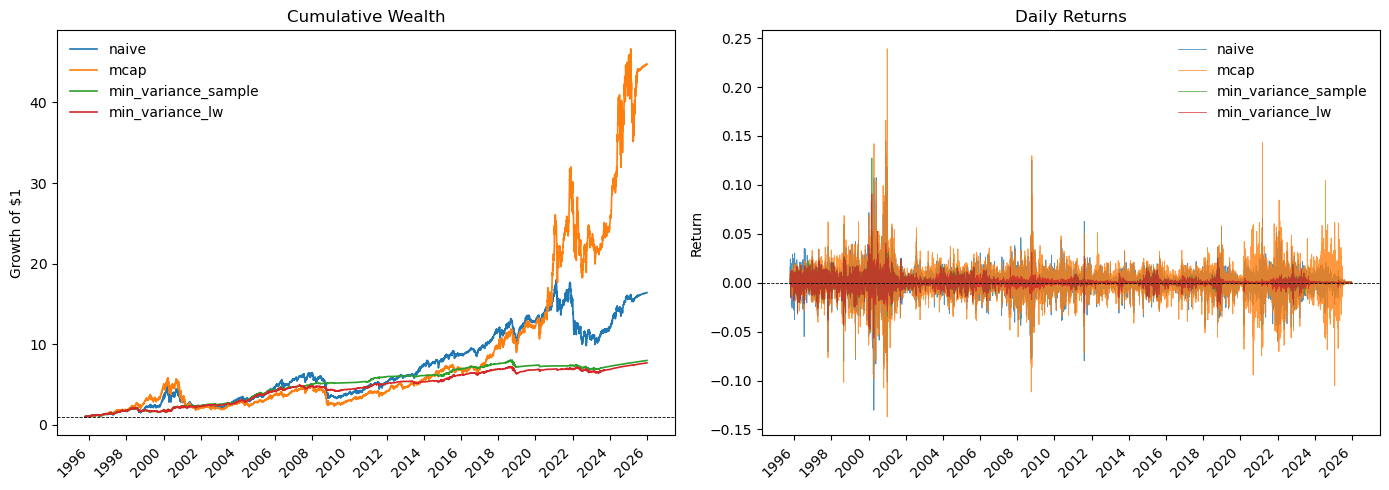

In [4]:
visualization = plot_portfolios(pd.concat(portfolio_timeseries, axis = 1))

## Nexts possible steps

* Include transaction costs
* Implement Sharpe ratio maximization
* Change stock selection mechanism